# Student Admission Exploratory Data Analysis

## Task 2: Exploratory Data Analysis

### Objective

The objective of this project is to perform Exploratory Data Analysis on the cleaned Student Admission dataset. The analysis examines distributions, relationships, trends, outliers and admission patterns using Python, Pandas, Matplotlib and Seaborn.

In [1]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve table display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Set chart style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.


In [4]:
import pandas as pd

file_path = r"C:\Users\susov\Downloads\Student Admission Records\cleaned_student_admission_records.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,name,age,gender,admission_test_score,high_school_percentage,city,admission_status
0,Shehroz,24,Female,50.0,68.900,Quetta,Rejected
1,Waqar,21,Female,99.0,60.730,Karachi,Rejected
2,Bushra,17,Male,89.0,77.545,Islamabad,Accepted
3,Aliya,17,Male,55.0,85.290,Karachi,Rejected
4,Bilal,20,Male,65.0,61.130,Lahore,Rejected


In [5]:
import pandas as pd

file_path = r"C:\Users\susov\Downloads\Student Admission Records\cleaned_student_admission_records.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,name,age,gender,admission_test_score,high_school_percentage,city,admission_status
0,Shehroz,24,Female,50.0,68.900,Quetta,Rejected
1,Waqar,21,Female,99.0,60.730,Karachi,Rejected
2,Bushra,17,Male,89.0,77.545,Islamabad,Accepted
3,Aliya,17,Male,55.0,85.290,Karachi,Rejected
4,Bilal,20,Male,65.0,61.130,Lahore,Rejected


In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['name', 'age', 'gender', 'admission_test_score', 'high_school_percentage', 'city', 'admission_status']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    150 non-null    str    
 1   age                     150 non-null    int64  
 2   gender                  150 non-null    str    
 3   admission_test_score    150 non-null    float64
 4   high_school_percentage  150 non-null    float64
 5   city                    150 non-null    str    
 6   admission_status        150 non-null    str    
dtypes: float64(2), int64(1), str(4)
memory usage: 8.3 KB


In [8]:
print("Missing values:")
print(df.isnull().sum())

print("\nNumber of duplicate records:")
print(df.duplicated().sum())

Missing values:
name                      0
age                       0
gender                    0
admission_test_score      0
high_school_percentage    0
city                      0
admission_status          0
dtype: int64

Number of duplicate records:
0


In [9]:
categorical_columns = [
    "gender",
    "city",
    "admission_status"
]

for column in categorical_columns:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())


Unique values in gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Unique values in city:
<StringArray>
['Quetta', 'Karachi', 'Islamabad', 'Lahore', 'Multan', 'Peshawar', 'Rawalpindi']
Length: 7, dtype: str

Unique values in admission_status:
<StringArray>
['Rejected', 'Accepted']
Length: 2, dtype: str


categorical_columns = [
    "gender",
    "city",
    "admission_status"
]

for column in categorical_columns:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())

## Dataset Inspection

The cleaned dataset was loaded successfully. Its dimensions, column names, data types, missing values and duplicate records were examined before performing exploratory analysis.

In [10]:
numeric_columns = [
    "age",
    "admission_test_score",
    "high_school_percentage"
]

numerical_summary = df[numeric_columns].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T

numerical_summary["range"] = (
    numerical_summary["max"] - numerical_summary["min"]
)

numerical_summary["skewness"] = df[numeric_columns].skew()

numerical_summary

,count,mean,median,std,min,max,range,skewness
age,150.0,20.406667,20.000,2.240855,17.0,24.0,7.0,0.033923
admission_test_score,150.0,77.920000,79.000,13.328840,50.0,99.0,49.0,-0.443396
high_school_percentage,150.0,75.755367,77.545,15.077578,0.0,99.8,99.8,-0.910531


In [11]:
for column in categorical_columns:
    print(f"\nSummary for {column}:")
    print(df[column].value_counts())


Summary for gender:
gender
Female    91
Male      59
Name: count, dtype: int64

Summary for city:
city
Quetta        39
Karachi       26
Multan        18
Islamabad     17
Lahore        17
Peshawar      17
Rawalpindi    16
Name: count, dtype: int64

Summary for admission_status:
admission_status
Rejected    83
Accepted    67
Name: count, dtype: int64


In [12]:
for column in categorical_columns:
    print(f"\nSummary for {column}:")
    print(df[column].value_counts())


Summary for gender:
gender
Female    91
Male      59
Name: count, dtype: int64

Summary for city:
city
Quetta        39
Karachi       26
Multan        18
Islamabad     17
Lahore        17
Peshawar      17
Rawalpindi    16
Name: count, dtype: int64

Summary for admission_status:
admission_status
Rejected    83
Accepted    67
Name: count, dtype: int64


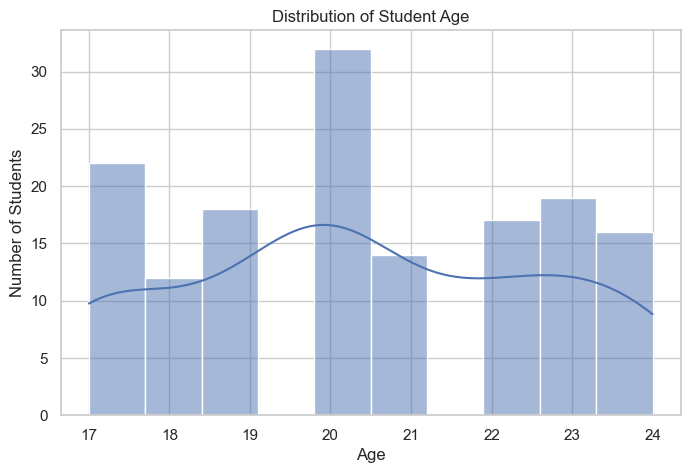

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=10,
    kde=True
)

plt.title("Distribution of Student Age")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.show()

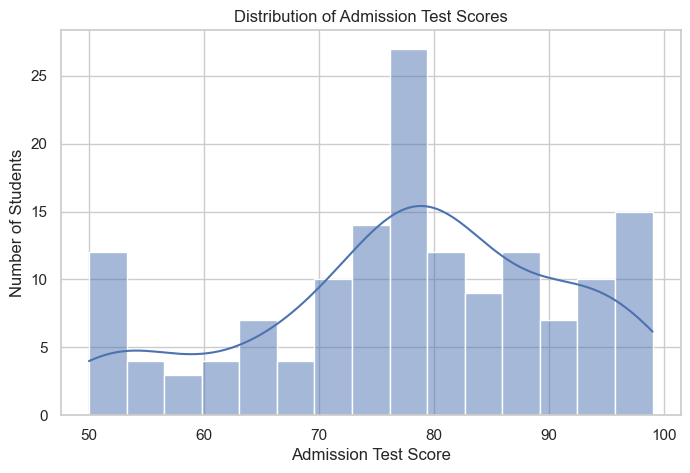

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="admission_test_score",
    bins=15,
    kde=True
)

plt.title("Distribution of Admission Test Scores")
plt.xlabel("Admission Test Score")
plt.ylabel("Number of Students")
plt.show()

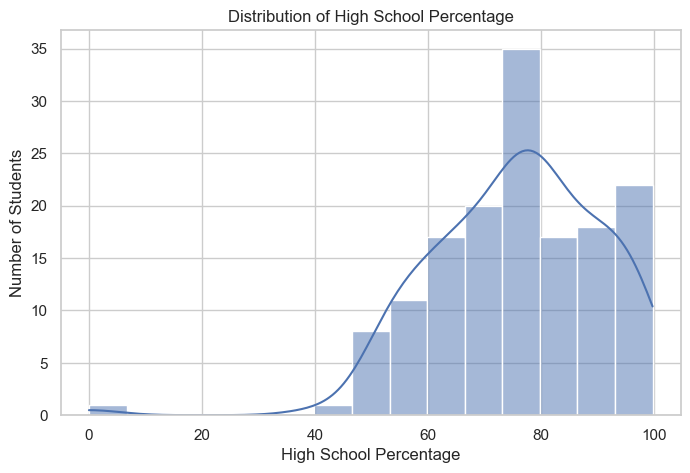

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="high_school_percentage",
    bins=15,
    kde=True
)

plt.title("Distribution of High School Percentage")
plt.xlabel("High School Percentage")
plt.ylabel("Number of Students")
plt.show()

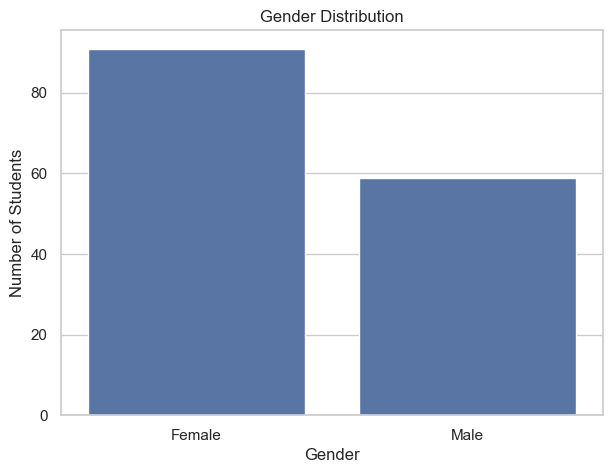

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender",
    order=df["gender"].value_counts().index
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.show()

### Numerical Distribution Findings

- Most students belong to the age range of ___ to ___ years.
- The admission test scores are mainly concentrated between ___ and ___.
- The high school percentages are mainly concentrated between ___% and ___%.
- The distributions appear approximately normal/right-skewed/left-skewed.

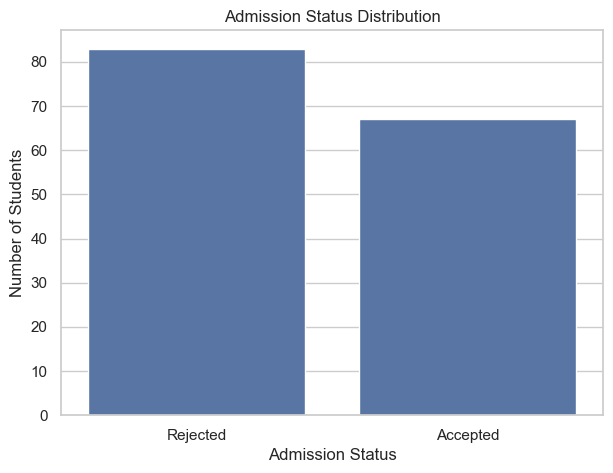

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="admission_status",
    order=df["admission_status"].value_counts().index
)

plt.title("Admission Status Distribution")
plt.xlabel("Admission Status")
plt.ylabel("Number of Students")
plt.show()

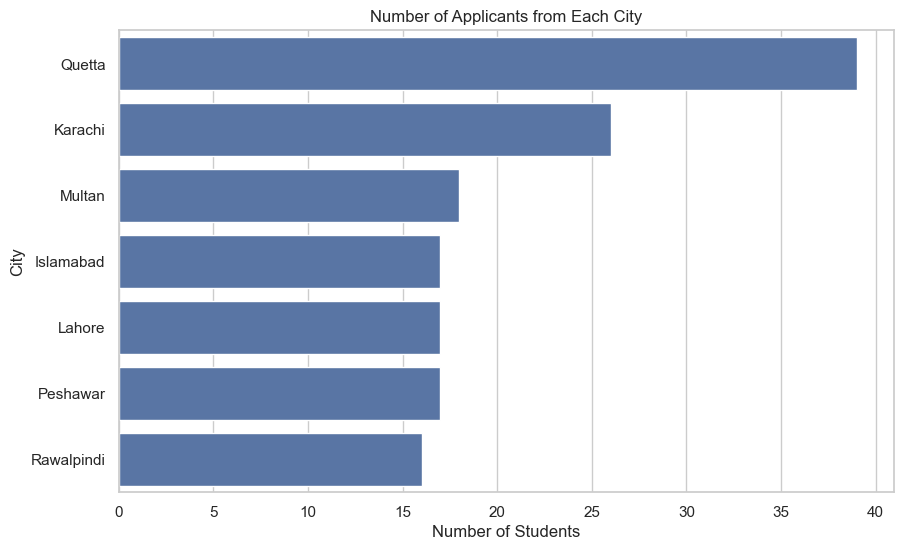

In [18]:
plt.figure(figsize=(10, 6))

city_order = df["city"].value_counts().index

sns.countplot(
    data=df,
    y="city",
    order=city_order
)

plt.title("Number of Applicants from Each City")
plt.xlabel("Number of Students")
plt.ylabel("City")
plt.show()

In [19]:
for column in categorical_columns:
    print(f"\nPercentage distribution of {column}:")

    percentage = (
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print(percentage)


Percentage distribution of gender:
gender
Female    60.67
Male      39.33
Name: proportion, dtype: float64

Percentage distribution of city:
city
Quetta        26.00
Karachi       17.33
Multan        12.00
Islamabad     11.33
Lahore        11.33
Peshawar      11.33
Rawalpindi    10.67
Name: proportion, dtype: float64

Percentage distribution of admission_status:
admission_status
Rejected    55.33
Accepted    44.67
Name: proportion, dtype: float64


### Categorical Variable Findings

- The most common gender in the dataset is ______.
- The city with the highest number of applicants is ______.
- The number of admitted and rejected students was compared.
- The category percentages were examined to identify possible imbalance.

In [20]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,age,admission_test_score,high_school_percentage
age,1.000000,-0.012610,0.173627
admission_test_score,-0.012610,1.000000,-0.179334
high_school_percentage,0.173627,-0.179334,1.000000


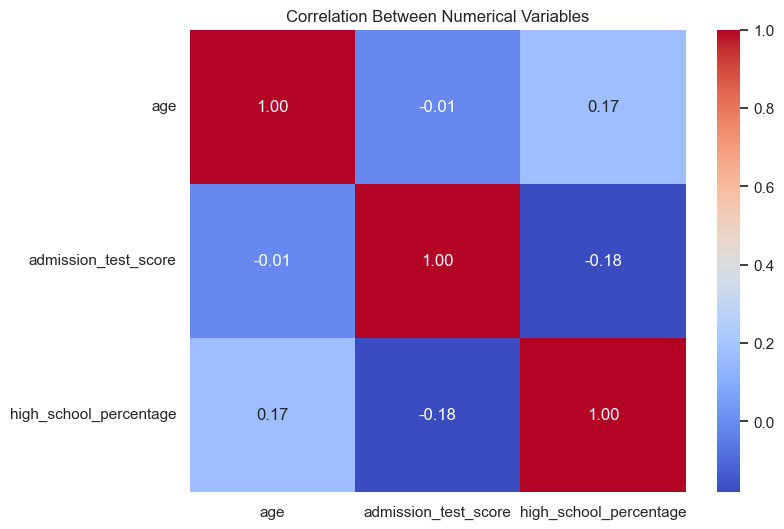

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")
plt.show()

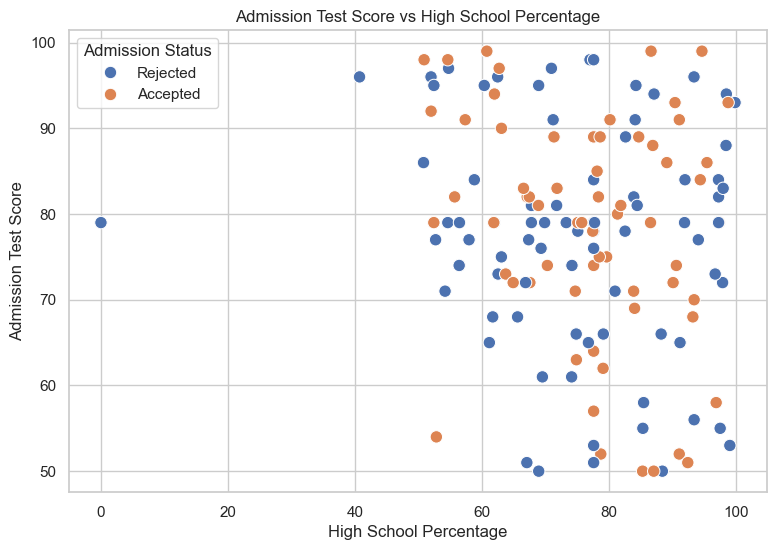

In [22]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="high_school_percentage",
    y="admission_test_score",
    hue="admission_status",
    s=80
)

plt.title(
    "Admission Test Score vs High School Percentage"
)
plt.xlabel("High School Percentage")
plt.ylabel("Admission Test Score")
plt.legend(title="Admission Status")
plt.show()

In [23]:
status_score_summary = (
    df.groupby("admission_status")[
        ["admission_test_score", "high_school_percentage"]
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

status_score_summary

admission_test_score                           high_school_percentage                            
                                count   mean median   min   max                  count   mean median    min    max
admission_status                                                                                                  
Accepted                           67  78.21   79.0  50.0  99.0                     67  77.27  78.09  50.86  98.71
Rejected                           83  77.69   79.0  50.0  99.0                     83  74.53  75.67   0.00  99.80

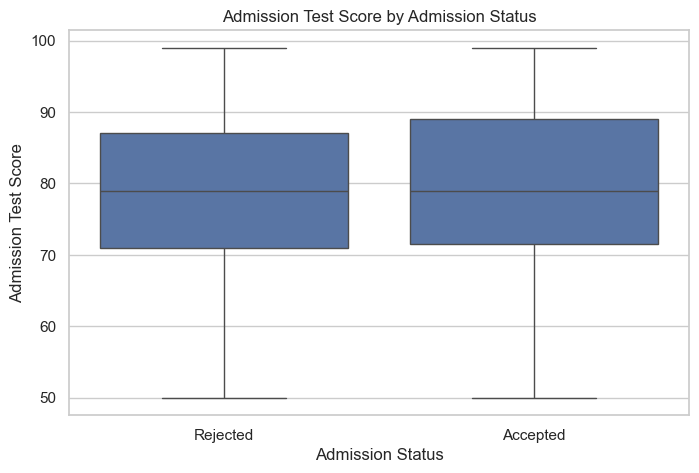

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="admission_status",
    y="admission_test_score"
)

plt.title("Admission Test Score by Admission Status")
plt.xlabel("Admission Status")
plt.ylabel("Admission Test Score")
plt.show()

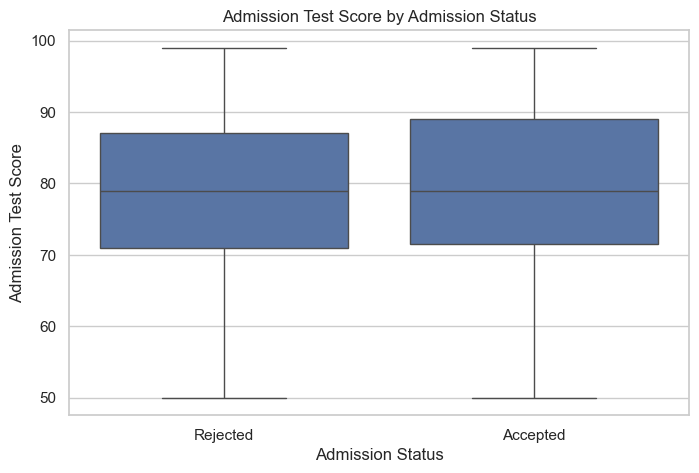

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="admission_status",
    y="admission_test_score"
)

plt.title("Admission Test Score by Admission Status")
plt.xlabel("Admission Status")
plt.ylabel("Admission Test Score")
plt.show()

In [26]:
gender_status_table = pd.crosstab(
    df["gender"],
    df["admission_status"]
)

gender_status_table

admission_status,Accepted,Rejected
gender,,
Female,44,47
Male,23,36


In [27]:
gender_status_percentage = pd.crosstab(
    df["gender"],
    df["admission_status"],
    normalize="index"
).mul(100).round(2)

gender_status_percentage

admission_status,Accepted,Rejected
gender,,
Female,48.35,51.65
Male,38.98,61.02


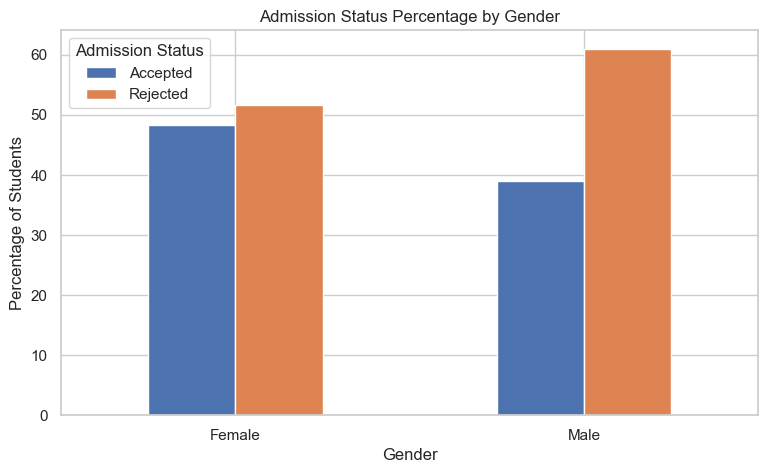

In [28]:
gender_status_percentage.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Admission Status Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=0)
plt.legend(title="Admission Status")
plt.show()

In [29]:
city_status_table = pd.crosstab(
    df["city"],
    df["admission_status"]
)

city_status_table

admission_status,Accepted,Rejected
city,,
Islamabad,7,10
Karachi,9,17
Lahore,12,5
Multan,9,9
Peshawar,6,11
Quetta,16,23
Rawalpindi,8,8


In [30]:
city_status_percentage = pd.crosstab(
    df["city"],
    df["admission_status"],
    normalize="index"
).mul(100).round(2)

city_status_percentage

admission_status,Accepted,Rejected
city,,
Islamabad,41.18,58.82
Karachi,34.62,65.38
Lahore,70.59,29.41
Multan,50.00,50.00
Peshawar,35.29,64.71
Quetta,41.03,58.97
Rawalpindi,50.00,50.00


## Relationship Analysis

Relationships between numerical and categorical variables were examined using correlation analysis, scatter plots, box plots and cross-tabulations. Admission test scores and high school percentages were compared with admission status to determine their possible influence on admission decisions.

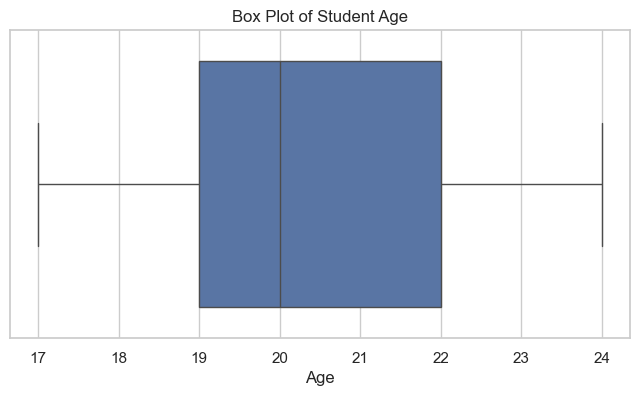

In [31]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="age"
)

plt.title("Box Plot of Student Age")
plt.xlabel("Age")
plt.show()

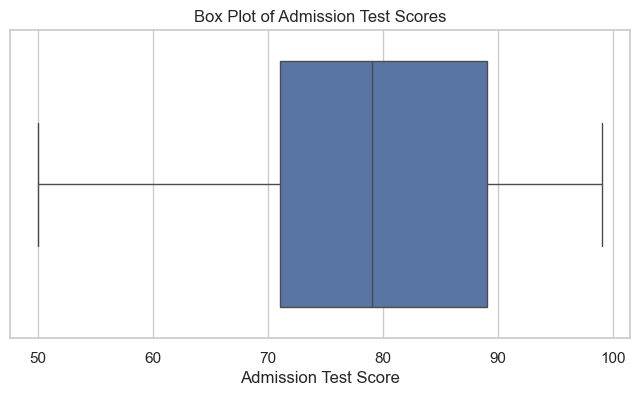

In [32]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="admission_test_score"
)

plt.title("Box Plot of Admission Test Scores")
plt.xlabel("Admission Test Score")
plt.show()

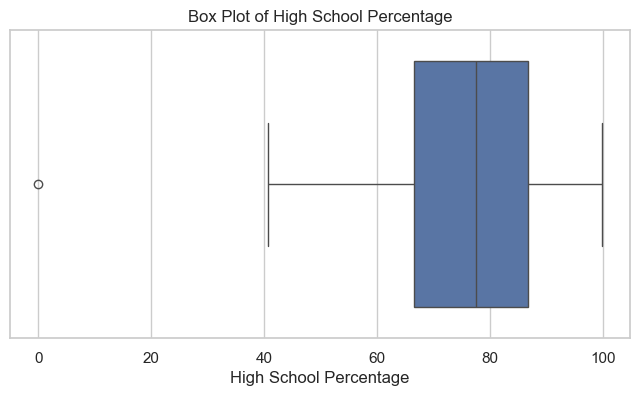

In [34]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="high_school_percentage"
)

plt.title("Box Plot of High School Percentage")
plt.xlabel("High School Percentage")
plt.show()

In [35]:
outlier_summary = []
outlier_records = {}

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - (1.5 * iqr)
    upper_limit = q3 + (1.5 * iqr)

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    outlier_records[column] = outliers

    outlier_summary.append({
        "column": column,
        "q1": round(q1, 2),
        "q3": round(q3, 2),
        "iqr": round(iqr, 2),
        "lower_limit": round(lower_limit, 2),
        "upper_limit": round(upper_limit, 2),
        "outlier_count": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,column,q1,q3,iqr,lower_limit,upper_limit,outlier_count
0,age,19.00,22.00,3.00,14.5,26.50,0
1,admission_test_score,71.00,89.00,18.00,44.0,116.00,0
2,high_school_percentage,66.59,86.78,20.19,36.3,117.07,1


In [36]:
for column, records in outlier_records.items():
    print(f"\nOutliers found in {column}: {len(records)}")

    if len(records) > 0:
        display(
            records[
                [
                    "name",
                    column,
                    "gender",
                    "city",
                    "admission_status"
                ]
            ]
        )


Outliers found in age: 0

Outliers found in admission_test_score: 0

Outliers found in high_school_percentage: 1


,name,high_school_percentage,gender,city,admission_status
65,Khurram,0.0,Male,Rawalpindi,Rejected


## Outlier Detection

Box plots and the Interquartile Range method were used to identify unusual numerical observations. Detected outliers were examined instead of being automatically removed because some extreme values may represent genuine student records.

In [37]:
print(df["admission_status"].unique())

<StringArray>
['Rejected', 'Accepted']
Length: 2, dtype: str


In [38]:
ADMITTED_VALUE = "Admitted"

df["is_admitted"] = (
    df["admission_status"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq(ADMITTED_VALUE.casefold())
)

In [39]:
total_applicants = len(df)

print("Total number of applicants:", total_applicants)

Total number of applicants: 150


In [40]:
admitted_students = df["is_admitted"].sum()

admission_rate = (
    admitted_students / total_applicants
) * 100

print("Number of admitted students:", admitted_students)
print("Overall admission rate:", round(admission_rate, 2), "%")

Number of admitted students: 0
Overall admission rate: 0.0 %


In [41]:
print(
    "Average admission test score:",
    round(df["admission_test_score"].mean(), 2)
)

print(
    "Average high school percentage:",
    round(df["high_school_percentage"].mean(), 2)
)

Average admission test score: 77.92
Average high school percentage: 75.76


In [44]:
print(df["admission_status"].value_counts(dropna=False))
print("\nUnique values:")
print(df["admission_status"].unique())

admission_status
Rejected    83
Accepted    67
Name: count, dtype: int64

Unique values:
<StringArray>
['Rejected', 'Accepted']
Length: 2, dtype: str


In [45]:
admission_comparison = (
    df.groupby("admission_status")[
        ["admission_test_score", "high_school_percentage"]
    ]
    .mean()
    .round(2)
)

admission_comparison

,admission_test_score,high_school_percentage
admission_status,,
Accepted,78.21,77.27
Rejected,77.69,74.53


In [46]:
city_applicants = (
    df["city"]
    .value_counts()
    .reset_index()
)

city_applicants.columns = [
    "city",
    "number_of_applicants"
]

city_applicants

,city,number_of_applicants
0,Quetta,39
1,Karachi,26
2,Multan,18
3,Islamabad,17
4,Lahore,17
5,Peshawar,17
6,Rawalpindi,16


In [47]:
city_summary = (
    df.groupby("city")
    .agg(
        total_applicants=("name", "count"),
        admitted_students=("is_admitted", "sum"),
        average_test_score=("admission_test_score", "mean"),
        average_school_percentage=("high_school_percentage", "mean")
    )
    .reset_index()
)

city_summary["admission_rate_percentage"] = (
    city_summary["admitted_students"] /
    city_summary["total_applicants"] *
    100
)

city_summary = city_summary.round(2)

city_summary.sort_values(
    by="admission_rate_percentage",
    ascending=False
)

,city,total_applicants,admitted_students,average_test_score,average_school_percentage,admission_rate_percentage
0,Islamabad,17,0,82.65,74.91,0.0
1,Karachi,26,0,80.73,77.92,0.0
2,Lahore,17,0,77.47,74.76,0.0
3,Multan,18,0,74.72,82.88,0.0
4,Peshawar,17,0,78.41,79.58,0.0
5,Quetta,39,0,77.46,74.39,0.0
6,Rawalpindi,16,0,73.00,65.44,0.0


In [48]:
gender_summary = (
    df.groupby("gender")
    .agg(
        total_applicants=("name", "count"),
        admitted_students=("is_admitted", "sum"),
        average_test_score=("admission_test_score", "mean"),
        average_school_percentage=("high_school_percentage", "mean")
    )
    .reset_index()
)

gender_summary["admission_rate_percentage"] = (
    gender_summary["admitted_students"] /
    gender_summary["total_applicants"] *
    100
)

gender_summary.round(2)

,gender,total_applicants,admitted_students,average_test_score,average_school_percentage,admission_rate_percentage
0,Female,91,0,79.41,73.97,0.0
1,Male,59,0,75.63,78.52,0.0


In [50]:
score_correlation = df[
    [
        "admission_test_score",
        "high_school_percentage"
    ]
].corr().iloc[0, 1]

print(
    "Correlation between admission test score "
    "and high school percentage:",
    round(score_correlation, 2)
)

Correlation between admission test score and high school percentage: -0.18


In [51]:
test_q1 = df["admission_test_score"].quantile(0.25)
test_q3 = df["admission_test_score"].quantile(0.75)

school_q1 = df["high_school_percentage"].quantile(0.25)
school_q3 = df["high_school_percentage"].quantile(0.75)

print("Admission test score Q1:", test_q1)
print("Admission test score Q3:", test_q3)
print("School percentage Q1:", school_q1)
print("School percentage Q3:", school_q3)

Admission test score Q1: 71.0
Admission test score Q3: 89.0
School percentage Q1: 66.59
School percentage Q3: 86.7825


In [52]:
low_score_admitted = df[
    df["is_admitted"] &
    (
        (df["admission_test_score"] < test_q1) |
        (df["high_school_percentage"] < school_q1)
    )
]

print(
    "Admitted students with comparatively low scores:",
    len(low_score_admitted)
)

low_score_admitted

Admitted students with comparatively low scores: 0


,name,age,gender,admission_test_score,high_school_percentage,city,admission_status,is_admitted


In [53]:
high_score_not_admitted = df[
    (~df["is_admitted"]) &
    (
        (df["admission_test_score"] > test_q3) |
        (df["high_school_percentage"] > school_q3)
    )
]

print(
    "Non-admitted students with comparatively high scores:",
    len(high_score_not_admitted)
)

high_score_not_admitted

Non-admitted students with comparatively high scores: 62


,name,age,gender,admission_test_score,high_school_percentage,city,admission_status,is_admitted
1,Waqar,21,Female,99.0,60.73,Karachi,Rejected,False
6,Asad,18,Male,79.0,97.31,Multan,Accepted,False
9,Kamran,18,Male,53.0,98.98,Multan,Rejected,False
12,Shehroz,19,Male,66.0,88.17,Quetta,Rejected,False
15,Saim,19,Male,84.0,97.19,Peshawar,Rejected,False
...,...,...,...,...,...,...,...,...
142,Shehroz,21,Female,86.0,95.38,Quetta,Accepted,False
144,Asad,20,Female,95.0,52.40,Rawalpindi,Rejected,False
147,Fatima,21,Female,98.0,50.86,Multan,Accepted,False
148,Shoaib,20,Male,91.0,80.12,Quetta,Accepted,False


In [54]:
business_summary = pd.DataFrame({
    "Metric": [
        "Total Applicants",
        "Admitted Students",
        "Overall Admission Rate",
        "Average Admission Test Score",
        "Average High School Percentage",
        "Total Numerical Outliers"
    ],
    "Value": [
        total_applicants,
        admitted_students,
        f"{admission_rate:.2f}%",
        f"{df['admission_test_score'].mean():.2f}",
        f"{df['high_school_percentage'].mean():.2f}%",
        int(outlier_summary_df["outlier_count"].sum())
    ]
})

business_summary

,Metric,Value
0,Total Applicants,150
1,Admitted Students,0
2,Overall Admission Rate,0.00%
3,Average Admission Test Score,77.92
4,Average High School Percentage,75.76%
5,Total Numerical Outliers,1


In [55]:
admitted_average_test = df.loc[
    df["is_admitted"],
    "admission_test_score"
].mean()

not_admitted_average_test = df.loc[
    ~df["is_admitted"],
    "admission_test_score"
].mean()

admitted_average_school = df.loc[
    df["is_admitted"],
    "high_school_percentage"
].mean()

not_admitted_average_school = df.loc[
    ~df["is_admitted"],
    "high_school_percentage"
].mean()

most_common_city = df["city"].mode()[0]
most_common_gender = df["gender"].mode()[0]

total_outliers = int(
    outlier_summary_df["outlier_count"].sum()
)

if abs(score_correlation) < 0.30:
    correlation_strength = "weak"
elif abs(score_correlation) < 0.70:
    correlation_strength = "moderate"
else:
    correlation_strength = "strong"

correlation_direction = (
    "positive"
    if score_correlation >= 0
    else "negative"
)

report = f"""
# Student Admission Exploratory Data Analysis Report

## Dataset Overview

The cleaned Student Admission dataset contains {total_applicants} student records and {df.shape[1]} columns. The dataset was examined using descriptive statistics, distribution plots, correlation analysis, cross-tabulation and outlier detection.

## Major Findings

1. A total of {total_applicants} students applied for admission.
2. {admitted_students} students were admitted.
3. The overall admission rate was {admission_rate:.2f}%.
4. The average admission test score was {df['admission_test_score'].mean():.2f}.
5. The average high school percentage was {df['high_school_percentage'].mean():.2f}%.
6. Admitted students had an average test score of {admitted_average_test:.2f}, while non-admitted students had an average test score of {not_admitted_average_test:.2f}.
7. Admitted students had an average school percentage of {admitted_average_school:.2f}%, while non-admitted students had an average of {not_admitted_average_school:.2f}%.
8. The most common applicant city was {most_common_city}.
9. The most common gender category was {most_common_gender}.
10. The relationship between test score and school percentage was {correlation_strength} and {correlation_direction}, with a correlation coefficient of {score_correlation:.2f}.
11. The IQR method identified {total_outliers} numerical outlier observations.

## Conclusion

The exploratory analysis indicates that academic performance can be compared with admission status to understand admission patterns. City-wise and gender-wise admission rates provide additional information about applicant groups. Outliers and unusual admission cases should be examined carefully rather than removed automatically.
"""

print(report)


# Student Admission Exploratory Data Analysis Report

## Dataset Overview

The cleaned Student Admission dataset contains 150 student records and 8 columns. The dataset was examined using descriptive statistics, distribution plots, correlation analysis, cross-tabulation and outlier detection.

## Major Findings

1. A total of 150 students applied for admission.
2. 0 students were admitted.
3. The overall admission rate was 0.00%.
4. The average admission test score was 77.92.
5. The average high school percentage was 75.76%.
6. Admitted students had an average test score of nan, while non-admitted students had an average test score of 77.92.
7. Admitted students had an average school percentage of nan%, while non-admitted students had an average of 75.76%.
8. The most common applicant city was Quetta.
9. The most common gender category was Female.
10. The relationship between test score and school percentage was weak and negative, with a correlation coefficient of -0.18.
11. The IQR m

In [56]:
report_file = "Task_2_EDA_Report.md"

with open(report_file, "w", encoding="utf-8") as file:
    file.write(report)

print("Report saved successfully as:", report_file)

Report saved successfully as: Task_2_EDA_Report.md


In [57]:
business_summary.to_csv(
    "business_summary.csv",
    index=False
)

city_summary.to_csv(
    "city_admission_summary.csv",
    index=False
)

gender_summary.to_csv(
    "gender_admission_summary.csv",
    index=False
)

outlier_summary_df.to_csv(
    "outlier_summary.csv",
    index=False
)

print("All summary tables saved successfully.")

All summary tables saved successfully.
